#Notebook 6: Risk Engine and Decision Intelligence


This notebook builds MeridianIQ's risk engine and decision intelligence layer.

Previous notebooks identified clauses, created contract fingerprints, and retrieved supporting evidence. This notebook converts those structured legal facts into business-facing risk scores, risk bands, risk drivers, recommendations, and contract intelligence summaries.

The goal is to move beyond clause detection and answer the more important business question: “How risky is this contract, and why?”

##Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import json,joblib
import matplotlib.pyplot as plt
import seaborn as sns

from fingerprint_builder import *

pd.set_option("display.max_columns",None)
pd.set_option("display.max_colwidth",250)


##Loading Contract Fingerprints and Risk Configuration

This step loads the processed contract fingerprints and the clause risk configuration created earlier.

In [ ]:
fingerprints=pd.read_csv("mvp_contract_fingerprints.csv")
risk_config=pd.read_csv("clause_risk_config.csv")

fingerprints.shape,risk_config.shape


((510, 37), (33, 11))

##Loading the MVP Risk Configuration

In [ ]:
mvp_config=risk_config[risk_config["is_mvp_clause"]==True].copy()

mvp_config[
    [
        "clause_name",
        "risk_domain",
        "clause_role",
        "severity",
        "base_risk_weight",
        "risk_action"
    ]
].head()

,clause_name,risk_domain,clause_role,severity,base_risk_weight,risk_action
2,Non-Compete,Competition Risk,Risk if present,Critical,25,NaN
3,Exclusivity,Competition Risk,Risk if Present,Critical,25,Flag when present
4,No-Solicit Of Customers,Competition Risk,Risk if Present,Medium,10,Flag when present
5,No-Solicit Of Employees,Competition Risk,Risk if Present,Medium,10,Flag when present
7,Termination For Convenience,Lifecycle Risk,Risk if Missing,High,18,NaN


##Scoring Individual Contracts

This step defines the logic used to score a contract.

Each contract is evaluated clause by clause using the risk configuration.

A clause can increase risk in two ways:

1. It is risky when present.
2. It is risky when missing.

For example, an uncapped liability clause may increase risk when present, while an insurance clause may increase risk when missing.

This rule-based scoring approach keeps MeridianIQ transparent and explainable.

In [ ]:
def score_contract(contract_row,risk_config):
  risk_score=0
  risk_drivers=[]

  for _, config in risk_config.iterrows():
    clause_name=config["clause_name"]
    clause_col=to_snake_case(clause_name)
    clause_role=config["clause_role"]
    weight=config["base_risk_weight"]

    if clause_col not in contract_row.index:
      continue
    clause_present=bool(contract_row[clause_col])

    triggered=False

    if clause_role=="Risk if Present" and clause_present:
      triggered=True

    elif clause_role=="Risk if Absent" and not clause_present:
      triggered=True

    if triggered:
      risk_score+=weight
      risk_drivers.append({
          "clause_name":clause_name,
          "risk_domain":config["risk_domain"],
          "clause_role":clause_role,
          "severity":config["severity"],
          "risk_weight":weight,
          "business_description":config["business_description"]

      })

      risk_score=min(risk_score,100)




  return risk_score,risk_drivers



##Assigning Risk Bands

A raw numerical score is useful for computation, but business users need interpretable categories.

This step converts the numerical risk score into a risk band:

Low Risk
Moderate Risk
High Risk
Critical Risk

Risk bands make the output easier to understand in dashboards, reports, and executive summaries.

In [ ]:
def assign_risk_band(score):

  if score<=25:
    return "Low Risk"
  elif score<=50:
    return "Moderate Risk"
  elif score<=75:
    return "High Risk"
  else:
    return "Critical Risk"

##Scoring All Contracts

The scoring logic is applied to every contract in the fingerprint dataset.

For each contract, MeridianIQ calculates:

1. Total risk score
2. Risk band
3. Number of triggered risk drivers
4. Clause-level risk explanations

This creates the main risk scoring output used by later notebooks and the final demo pipeline.

In [ ]:
risk_records=[]
driver_records=[]

for _,row in fingerprints.iterrows():
  score,drivers=score_contract(row,mvp_config)
  band=assign_risk_band(score)

  risk_records.append({
      "filename":row["filename"],
      "document_name":row.get("document_name",None),
      "risk_score":score,
      "risk_band":band,
      "num_risk_drivers":len(drivers)
  })

  for driver in drivers:
    driver_records.append({
        "filename":row["filename"],
        **driver
    })

contract_risk_scores=pd.DataFrame(risk_records)
risk_driver_table=pd.DataFrame(driver_records)

contract_risk_scores.head()

,filename,document_name,risk_score,risk_band,num_risk_drivers
0,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605784_EX-10.27_Affiliate Agreement.pdf,MARKETING AFFILIATE AGREEMENT,0,Low Risk,0
1,EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B(01)_525118_EX-10.B(01)_Content License Agreement.pdf,VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT,18,Low Risk,1
2,FulucaiProductionsLtd_20131223_10-Q_EX-10.9_8368347_EX-10.9_Content License Agreement.pdf,CONTENT DISTRIBUTION AND LICENSE AGREEMENT,43,Moderate Risk,2
3,GopageCorp_20140221_10-K_EX-10.1_8432966_EX-10.1_Content License Agreement.pdf,WEBSITE CONTENT LICENSE AGREEMENT,25,Low Risk,1
4,IdeanomicsInc_20160330_10-K_EX-10.26_9512211_EX-10.26_Content License Agreement.pdf,CONTENT LICENSE AGREEMENT,0,Low Risk,0


##Building the Risk Driver Table

The risk driver table stores the specific clauses that contributed to each contract's risk score.

This is important because a risk score alone is not explainable.

In [ ]:
risk_driver_table.head()

,filename,clause_name,risk_domain,clause_role,severity,risk_weight,business_description
0,EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B(01)_525118_EX-10.B(01)_Content License Agreement.pdf,Unlimited/All-You-Can-Eat-License,IP Risk,Risk if Present,High,18,Grants broad or unlimited usage rights.
1,FulucaiProductionsLtd_20131223_10-Q_EX-10.9_8368347_EX-10.9_Content License Agreement.pdf,Exclusivity,Competition Risk,Risk if Present,Critical,25,Creates exclusive dealing obligations that may limit business flexibility.
2,FulucaiProductionsLtd_20131223_10-Q_EX-10.9_8368347_EX-10.9_Content License Agreement.pdf,Unlimited/All-You-Can-Eat-License,IP Risk,Risk if Present,High,18,Grants broad or unlimited usage rights.
3,GopageCorp_20140221_10-K_EX-10.1_8432966_EX-10.1_Content License Agreement.pdf,Exclusivity,Competition Risk,Risk if Present,Critical,25,Creates exclusive dealing obligations that may limit business flexibility.
4,EdietsComInc_20001030_10QSB_EX-10.4_2606646_EX-10.4_Co-Branding Agreement.pdf,Exclusivity,Competition Risk,Risk if Present,Critical,25,Creates exclusive dealing obligations that may limit business flexibility.


##Recommendation Engine

Risk detection is only useful if it leads to action.

This step maps each triggered risk driver to a recommended business review action.

For example, if insurance is missing, MeridianIQ recommends reviewing whether insurance obligations should be added.

These recommendations make the output practical for business users rather than purely analytical.

In [ ]:
recommendation_map = {
    "Uncapped Liability": "Review liability exposure and consider adding or narrowing liability caps.",
    "Cap On Liability": "Consider adding a liability cap to limit financial exposure.",
    "Insurance": "Consider adding insurance obligations to protect against operational or financial losses.",
    "Non-Compete": "Review competitive restrictions for enforceability and business flexibility.",
    "Exclusivity": "Review exclusivity obligations and assess whether they restrict future business opportunities.",
    "No-Solicit Of Customers": "Review customer non-solicitation restrictions for scope and duration.",
    "No-Solicit Of Employees": "Review employee non-solicitation restrictions for scope and duration.",
    "Termination For Convenience": "Consider adding a termination-for-convenience right for flexibility.",
    "Post-Termination Services": "Review post-termination obligations and estimate operational burden.",
    "Minimum Commitment": "Review minimum purchase or payment obligations.",
    "Revenue/Profit Sharing": "Review revenue or profit sharing obligations and financial impact.",
    "Price Restrictions": "Review restrictions on pricing flexibility.",
    "Volume Restriction": "Review usage or volume thresholds and related penalties.",
    "Ip Ownership Assignment": "Review intellectual property ownership transfer language carefully.",
    "Joint Ip Ownership": "Clarify rights and responsibilities for jointly owned intellectual property.",
    "Irrevocable Or Perpetual License": "Review long-term or irrevocable license rights for future business impact.",
    "Unlimited/All-You-Can-Eat-License": "Review broad license grants and usage limitations.",
    "Liquidated Damages": "Review preset damages or termination fees for financial exposure."
}

In [ ]:
risk_driver_table["recommendation"]=risk_driver_table["clause_name"].map(
    recommendation_map
)

risk_driver_table.head()

,filename,clause_name,risk_domain,clause_role,severity,risk_weight,business_description,recommendation
0,EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B(01)_525118_EX-10.B(01)_Content License Agreement.pdf,Unlimited/All-You-Can-Eat-License,IP Risk,Risk if Present,High,18,Grants broad or unlimited usage rights.,Review broad license grants and usage limitations.
1,FulucaiProductionsLtd_20131223_10-Q_EX-10.9_8368347_EX-10.9_Content License Agreement.pdf,Exclusivity,Competition Risk,Risk if Present,Critical,25,Creates exclusive dealing obligations that may limit business flexibility.,Review exclusivity obligations and assess whether they restrict future business opportunities.
2,FulucaiProductionsLtd_20131223_10-Q_EX-10.9_8368347_EX-10.9_Content License Agreement.pdf,Unlimited/All-You-Can-Eat-License,IP Risk,Risk if Present,High,18,Grants broad or unlimited usage rights.,Review broad license grants and usage limitations.
3,GopageCorp_20140221_10-K_EX-10.1_8432966_EX-10.1_Content License Agreement.pdf,Exclusivity,Competition Risk,Risk if Present,Critical,25,Creates exclusive dealing obligations that may limit business flexibility.,Review exclusivity obligations and assess whether they restrict future business opportunities.
4,EdietsComInc_20001030_10QSB_EX-10.4_2606646_EX-10.4_Co-Branding Agreement.pdf,Exclusivity,Competition Risk,Risk if Present,Critical,25,Creates exclusive dealing obligations that may limit business flexibility.,Review exclusivity obligations and assess whether they restrict future business opportunities.


##Risk Domain Summary

Triggered risks are grouped by risk domain.

This helps MeridianIQ explain which categories of business risk are most common across the contract set.

Instead of only listing individual clauses, the system can summarize broader areas such as:

1. Competition Risk
2. Liability Risk
3. IP Risk
4. Lifecycle Risk

In [ ]:
domain_summary=(
    risk_driver_table
    .groupby("risk_domain")
    .agg(
        total_triggers=("clause_name","count"),
        avg_weight=("risk_weight","mean")
    )
    .reset_index()
    .sort_values("total_triggers",ascending=False)
)

domain_summary

,risk_domain,total_triggers,avg_weight
0,Competition Risk,273,19.89011
2,Lifecycle Risk,182,18.00000
1,IP Risk,17,18.00000


##Visualizing Risk Band Distribution

This visualization shows how contracts are distributed across risk bands.

It helps answer a high-level business question:

“How risky is this contract portfolio overall?”

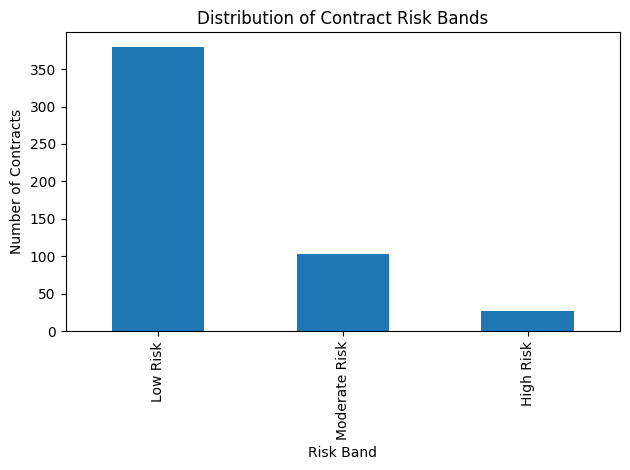

In [ ]:
contract_risk_scores["risk_band"].value_counts().plot(kind="bar")
plt.title("Distribution of Contract Risk Bands")
plt.xlabel("Risk Band")
plt.ylabel("Number of Contracts")
plt.tight_layout()
plt.show()


##Visualizing Risk Score Distribution

This plot shows the spread of numerical risk scores across contracts.

The goal is to understand whether most contracts are low risk, moderately risky, or concentrated near high-risk thresholds.

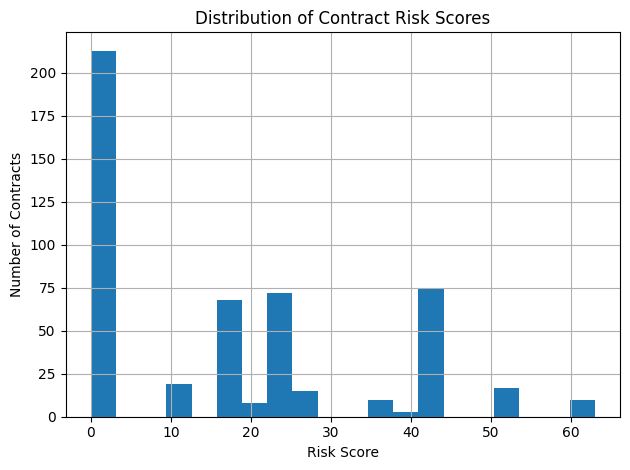

In [ ]:
contract_risk_scores["risk_score"].hist(bins=20)
plt.title("Distribution of Contract Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Number of Contracts")
plt.tight_layout()
plt.show()

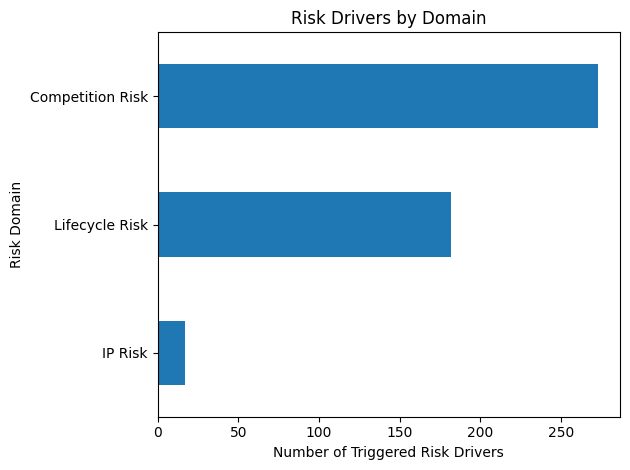

In [ ]:
domain_summary.sort_values("total_triggers").plot(
    kind="barh",
    x="risk_domain",
    y="total_triggers",
    legend=False
)
plt.title("Risk Drivers by Domain")
plt.xlabel("Number of Triggered Risk Drivers")
plt.ylabel("Risk Domain")
plt.tight_layout()
plt.show()

##Sample Contract Risk Report

This step selects a high-risk contract and inspects its triggered risk drivers.

The purpose is to verify that the risk score is explainable at the contract level.

A reviewer should be able to trace the final score back to the exact clauses, domains, severities, weights, and recommendations that caused it.

In [ ]:
sample_filename = contract_risk_scores.sort_values(
    "risk_score",
    ascending=False
).iloc[0]["filename"]

sample_score = contract_risk_scores[
    contract_risk_scores["filename"] == sample_filename
]

sample_drivers = risk_driver_table[
    risk_driver_table["filename"] == sample_filename
].sort_values("risk_weight", ascending=False)

sample_score

,filename,document_name,risk_score,risk_band,num_risk_drivers
423,AIRTECHINTERNATIONALGROUPINC_05_08_2000-EX-10.4-FRANCHISE AGREEMENT.PDF,FRANCHISE AGREEMENT,63,High Risk,4


In [ ]:
sample_drivers[
    [
        "clause_name",
        "risk_domain",
        "severity",
        "risk_weight",
        "recommendation"
    ]
]

,clause_name,risk_domain,severity,risk_weight,recommendation
388,Exclusivity,Competition Risk,Critical,25,Review exclusivity obligations and assess whether they restrict future business opportunities.
391,Post-Termination Services,Lifecycle Risk,High,18,Review post-termination obligations and estimate operational burden.
389,No-Solicit Of Customers,Competition Risk,Medium,10,Review customer non-solicitation restrictions for scope and duration.
390,No-Solicit Of Employees,Competition Risk,Medium,10,Review employee non-solicitation restrictions for scope and duration.


##Checking MVP Risk Domain Coverage

This diagnostic step checks how many MVP clauses exist in each risk domain.

It verifies that the risk configuration covers multiple types of contract risk and is not overly concentrated in one area.

In [ ]:
mvp_config["risk_domain"].value_counts()

,count
risk_domain,
IP Risk,5
Financial Risk,4
Competition Risk,4
Liability Risk,4
Lifecycle Risk,2
Control Risk,2
Operational Risk,2


##Checking Triggered Risk Domains

This step checks which risk domains actually appear in the triggered risk driver table.

Not every configured domain will necessarily appear as a triggered risk, because some clauses are contextual and do not increase the score directly.

In [ ]:
risk_driver_table["risk_domain"].value_counts()

,count
risk_domain,
Competition Risk,273
Lifecycle Risk,182
IP Risk,17


##Building the Contract Intelligence Table

The risk driver table only contains clauses that actively affect scoring.

However, MeridianIQ should also retain broader contract intelligence, including contextual clauses that may not increase the risk score but are still important for understanding the agreement.

This step creates a contract intelligence table containing all MVP clauses for all contracts.

In [ ]:
intelligence_records = []

for _, contract in fingerprints.iterrows():
    for _, config in mvp_config.iterrows():
        clause_name = config["clause_name"]
        clause_col = to_snake_case(clause_name)

        if clause_col not in contract.index:
            continue

        clause_present = bool(contract[clause_col])

        intelligence_records.append({
            "filename": contract["filename"],
            "document_name": contract.get("document_name", None),
            "clause_name": clause_name,
            "risk_domain": config["risk_domain"],
            "clause_role": config["clause_role"],
            "severity": config["severity"],
            "clause_present": clause_present,
            "business_description": config["business_description"]
        })

contract_intelligence_table = pd.DataFrame(intelligence_records)

contract_intelligence_table.head()

,filename,document_name,clause_name,risk_domain,clause_role,severity,clause_present,business_description
0,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605784_EX-10.27_Affiliate Agreement.pdf,MARKETING AFFILIATE AGREEMENT,Non-Compete,Competition Risk,Risk if present,Critical,False,"Restricts a party from competing in certain markets, geographies, or sectors."
1,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605784_EX-10.27_Affiliate Agreement.pdf,MARKETING AFFILIATE AGREEMENT,Exclusivity,Competition Risk,Risk if Present,Critical,False,Creates exclusive dealing obligations that may limit business flexibility.
2,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605784_EX-10.27_Affiliate Agreement.pdf,MARKETING AFFILIATE AGREEMENT,No-Solicit Of Customers,Competition Risk,Risk if Present,Medium,False,Restricts solicitation of the counterparty’s customers or partners.
3,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605784_EX-10.27_Affiliate Agreement.pdf,MARKETING AFFILIATE AGREEMENT,No-Solicit Of Employees,Competition Risk,Risk if Present,Medium,False,Restricts hiring or solicitation of the counterparty’s employees.
4,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605784_EX-10.27_Affiliate Agreement.pdf,MARKETING AFFILIATE AGREEMENT,Termination For Convenience,Lifecycle Risk,Risk if Missing,High,False,Allows termination without cause after notice or waiting period.


##Contract Intelligence Domain Coverage

This step checks the domain distribution in the full contract intelligence table.

Unlike the risk driver table, this view includes every tracked MVP clause, whether or not it triggered risk.

In [ ]:
contract_intelligence_table["risk_domain"].value_counts()

,count
risk_domain,
IP Risk,2550
Financial Risk,2040
Competition Risk,2040
Liability Risk,2040
Lifecycle Risk,1020
Control Risk,1020
Operational Risk,1020


##Contract Intelligence Presence Summary

This step summarizes how often clauses are actually present within each risk domain.

In [ ]:
intelligence_domain_summary = (
    contract_intelligence_table
    .groupby("risk_domain")
    .agg(
        total_clauses_tracked=("clause_name", "count"),
        clauses_present=("clause_present", "sum")
    )
    .reset_index()
)

intelligence_domain_summary["presence_rate"] = (
    intelligence_domain_summary["clauses_present"] /
    intelligence_domain_summary["total_clauses_tracked"]
)

intelligence_domain_summary

,risk_domain,total_clauses_tracked,clauses_present,presence_rate
0,Competition Risk,2040,392,0.192157
1,Control Risk,1020,495,0.485294
2,Financial Risk,2040,428,0.209804
3,IP Risk,2550,512,0.200784
4,Liability Risk,2040,614,0.300980
5,Lifecycle Risk,1020,365,0.357843
6,Operational Risk,1020,289,0.283333


##Visualizing Clause Presence by Risk Domain

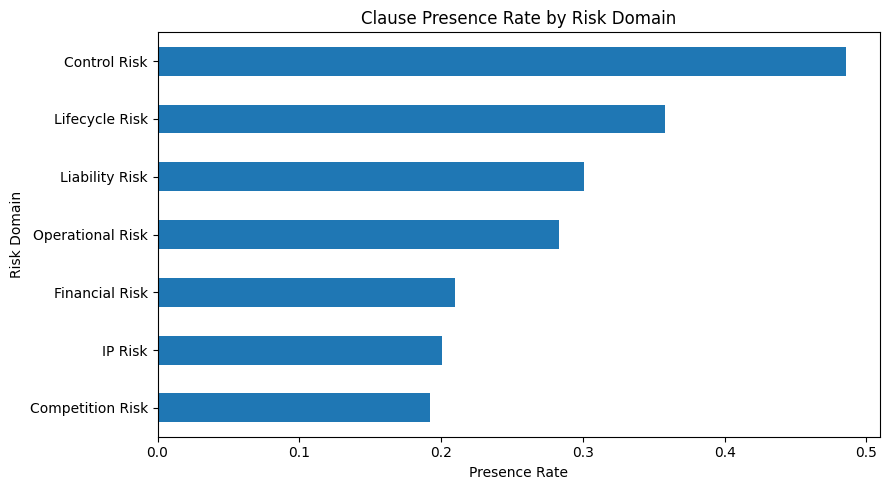

In [ ]:
intelligence_domain_summary.sort_values("presence_rate").plot(
    kind="barh",
    x="risk_domain",
    y="presence_rate",
    legend=False,
    figsize=(9, 5)
)

plt.title("Clause Presence Rate by Risk Domain")
plt.xlabel("Presence Rate")
plt.ylabel("Risk Domain")
plt.tight_layout()
plt.show()

##Detected MVP Clause Frequency

This visualization shows how often each MVP clause is present across contracts.

It helps identify which clauses are commonly detected and which are rare.

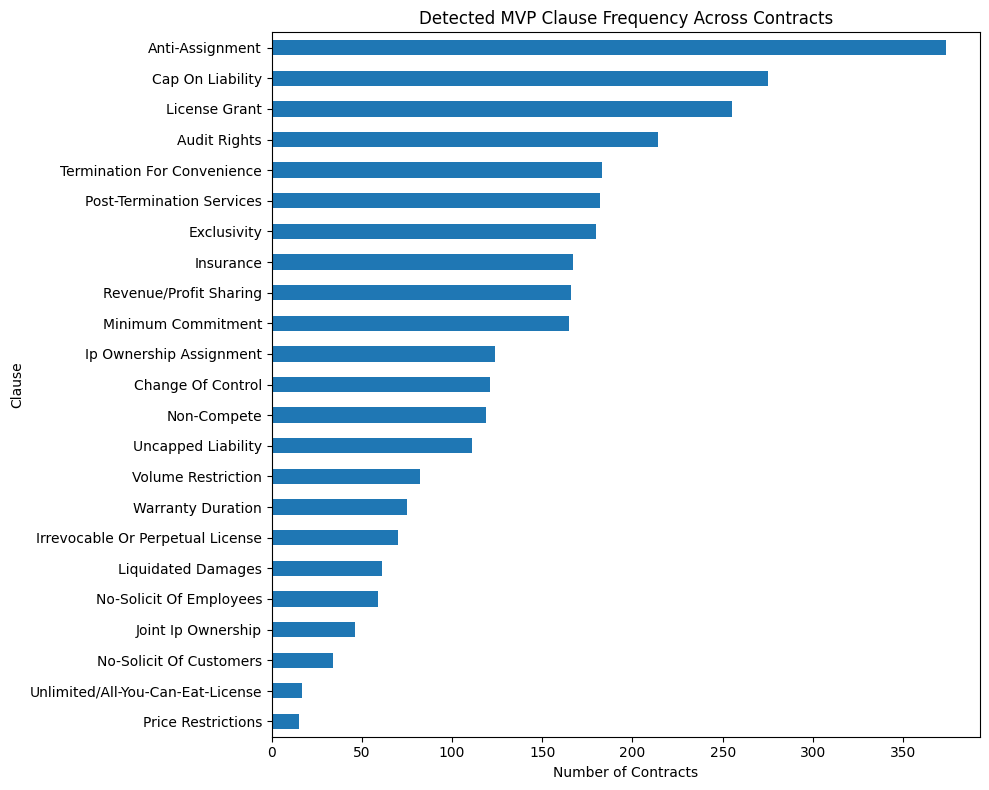

In [ ]:
present_clause_summary = (
    contract_intelligence_table[contract_intelligence_table["clause_present"] == True]
    .groupby("clause_name")
    .size()
    .sort_values(ascending=True)
)

present_clause_summary.plot(kind="barh", figsize=(10, 8))

plt.title("Detected MVP Clause Frequency Across Contracts")
plt.xlabel("Number of Contracts")
plt.ylabel("Clause")
plt.tight_layout()
plt.show()

##Exporting Risk and Intelligence Outputs

In [ ]:
contract_risk_scores.to_csv("contract_risk_scores.csv",index=False)
risk_driver_table.to_csv("risk_driver_table.csv",index=False)
domain_summary.to_csv("risk_domain_summary.csv",index=False)

risk_config.to_csv("risk_config.csv",index=False)
contract_intelligence_table.to_csv("contract_intelligence_table.csv",index=False)


## Notebook Summary

This notebook created MeridianIQ's decision intelligence layer.

It transformed structured contract fingerprints into:

* Risk scores
* Risk bands
* Clause-level risk drivers
* Business recommendations
* Risk domain summaries
* Contract intelligence coverage
* Portfolio-level visualizations

The most important architectural decision in this notebook is the separation between risk drivers and contract intelligence.

Risk drivers explain what increases risk.

Contract intelligence explains what the contract contains.

Together, these outputs allow MeridianIQ to generate business-facing contract review reports that are both explainable and actionable.